# RAG Self-Reflection Agent
### Changes made:
- ✅ Added logging to file (`rag_agent.log`) and console
- ✅ All prompts converted to `ChatPromptTemplate`
- ✅ Removed duplicate imports
- ✅ Added `load_dotenv()` call
- ✅ `MAX_ATTEMPTS` extracted as a config variable
- ✅ Added try/except error handling on LLM calls

In [17]:
#── Imports ───────────────────────────────────────────────────────────────────
import logging
import os
import operator
from typing import Annotated, List, Literal, Sequence

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain_community.document_loaders import PyPDFLoader
from langchain.chat_models import init_chat_model
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import END, START, StateGraph

In [18]:
#── Logging Setup ─────────────────────────────────────────────────────────────
# This runs once. It sets up logging to BOTH:
#   1. A file called 'rag_agent.log' saved on disk
#   2. The console (so you can still see logs in the notebook output)

logging.basicConfig(
    level=logging.INFO,   # Capture INFO, WARNING, ERROR, CRITICAL
    format="%(asctime)s [%(levelname)s] %(name)s - %(message)s",
    handlers=[
        logging.FileHandler("rag_agent.log"),   # <-- saves to disk
        logging.StreamHandler()                  # <-- prints to console
    ]
)

# Create a named logger for this module
logger = logging.getLogger("rag_agent")
logger.info("Logging initialized. Logs will be saved to 'rag_agent.log'")

2026-02-21 14:39:38,371 [INFO] rag_agent - Logging initialized. Logs will be saved to 'rag_agent.log'


In [19]:
#── Config ────────────────────────────────────────────────────────────────────
load_dotenv()   # FIX: was imported but never called before

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

MAX_ATTEMPTS = 2   # FIX: extracted magic number so it's easy to change

llm = init_chat_model("openai:gpt-4o")
logger.info("LLM model initialized: gpt-4o")

2026-02-21 14:39:38,385 [INFO] rag_agent - LLM model initialized: gpt-4o


In [20]:
#── Vector Store ──────────────────────────────────────────────────────────────
pdf_paths = [
    "./pdf/Earnings-Presentation-Q3-2025-Final.pdf",
    "./pdf/ICIBM 2025_submission_43_paper_v2.pdf",
]

docs = []
for path in pdf_paths:
    if os.path.exists(path):
        loader = PyPDFLoader(path)
        data = loader.load()
        docs.extend(data)
        logger.info(f"Loaded {len(data)} pages from {path}")
    else:
        logger.warning(f"File NOT found: {os.path.abspath(path)}")

if not docs:
    logger.error("No documents were loaded. Check your file paths!")
    raise ValueError("No documents were loaded. Check your file paths or PDF content!")

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(docs)
logger.info(f"Created {len(doc_splits)} text chunks")

if not doc_splits:
    logger.error("Splitting resulted in 0 chunks. Are the PDFs empty or images?")
    raise ValueError("Documents were loaded, but splitting resulted in 0 chunks.")

embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(documents=doc_splits, embedding=embedding)
logger.info("Vector store successfully built!")

2026-02-21 14:39:38,869 [INFO] rag_agent - Loaded 18 pages from ./pdf/Earnings-Presentation-Q3-2025-Final.pdf
2026-02-21 14:39:39,802 [INFO] rag_agent - Loaded 10 pages from ./pdf/ICIBM 2025_submission_43_paper_v2.pdf
2026-02-21 14:39:39,804 [INFO] rag_agent - Created 92 text chunks
2026-02-21 14:39:40,741 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-02-21 14:39:40,852 [INFO] rag_agent - Vector store successfully built!


In [21]:
#── Retriever ─────────────────────────────────────────────────────────────────
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
logger.info("Retriever created with k=5")

2026-02-21 14:39:40,859 [INFO] rag_agent - Retriever created with k=5


In [22]:
#── State ─────────────────────────────────────────────────────────────────────
class RAGReflectionState(BaseModel):
    original_question: str
    question: str
    # Annotated with operator.add so nodes APPEND to the list instead of overwrite
    retrieved_docs: List[Document] = []
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0
    next_step: str = ""
    context: str = ""  # <-- new field to hold context for reflection

In [23]:
#── Prompts (ChatPromptTemplate) ──────────────────────────────────────────────
# FIX: Replaced raw f-string prompts with ChatPromptTemplate

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Use the provided context to answer the user's question accurately."),
    ("human", "Context:\n{context}\n\nQuestion:\n{question}")
])

reflection_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You are evaluating an answer against the source documents. "
        "Only use the provided context as the source of truth — do not question "
        "whether the data is real or current.\n"
        "Respond strictly:\n"
        "Reflection: YES or NO\n"
        "Explanation: <your reasoning>"
    )),
    ("human", "Context:\n{context}\n\nQuestion: {question}\n\nAnswer: {answer}")
])

logger.info("Prompts defined using ChatPromptTemplate")

2026-02-21 14:39:40,877 [INFO] rag_agent - Prompts defined using ChatPromptTemplate


In [29]:
#── Nodes ─────────────────────────────────────────────────────────────────────

def retrieve_docs(state: RAGReflectionState) -> RAGReflectionState:
    logger.info(f"[retrieve_docs] Retrieving docs for question: '{state.question}'")
    docs = retriever.invoke(state.question)
    logger.info(f"[retrieve_docs] Retrieved {len(docs)} documents")
    return state.model_copy(update={"retrieved_docs": docs})


def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    logger.info(f"[generate_answer] Generating answer (attempt {state.attempts + 1})")
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    
    try:
        # FIX: Use ChatPromptTemplate instead of raw f-string
        chain = answer_prompt | llm | StrOutputParser()
        answer = chain.invoke({"context": context, "question": state.question})
        logger.info(f"[generate_answer] Answer generated successfully")
    except Exception as e:
        logger.error(f"[generate_answer] LLM call failed: {e}")
        answer = "Error generating answer."
    
    # This is where attempts gets incremented: state.attempts + 1
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})


def reflect_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    logger.info(f"[reflect_on_answer] Reflecting on answer (attempt {state.attempts})")
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    
    try:
        chain = reflection_prompt | llm | StrOutputParser()
        result = chain.invoke({
            "context": context,
            "question": state.original_question, 
            "answer": state.answer
        })
        is_ok = "reflection: yes" in result.lower() 
        logger.info(f"[reflect_on_answer] Reflection result: {'APPROVED' if is_ok else 'NEEDS REVISION'}")
    except Exception as e:
        logger.error(f"[reflect_on_answer] LLM call failed: {e}")
        result = "Error during reflection."
        is_ok = True

    return state.model_copy(update={"reflection": result, "revised": not is_ok})


def should_continue(state: RAGReflectionState) -> str:
    if not state.revised:
        logger.info("Routing: answer approved by reflector → END")
        return END
    if state.attempts >= MAX_ATTEMPTS:
        logger.warning(f"Routing: max attempts ({MAX_ATTEMPTS}) reached → END")
        return END
    logger.info(f"Routing: needs revision, attempt {state.attempts} → query_rewriter")
    return "query_rewriter"

rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are refining a search query to retrieve better documents. "
               "Given the original question and why the previous answer was insufficient, "
               "rewrite the query to be more specific."),
    ("human", "Original question: {question}\n\nWhy it failed: {reflection}\n\nRewritten query:")
])

def rewrite_query(state: RAGReflectionState) -> RAGReflectionState:
    logger.info("[rewrite_query] Rewriting query based on reflection feedback")
    try:
        chain = rewrite_prompt | llm | StrOutputParser()
        new_question = chain.invoke({
            "question": state.question,
            "reflection": state.reflection
        })
        logger.info(f"[rewrite_query] New query: '{new_question}'")
    except Exception as e:
        logger.error(f"[rewrite_query] Query rewrite failed: {e}, keeping original question")
        new_question = state.question   # fall back to original
    
    return state.model_copy(update={"question": new_question})


2026-02-21 14:46:19,552 [INFO] rag_agent - LangGraph compiled successfully


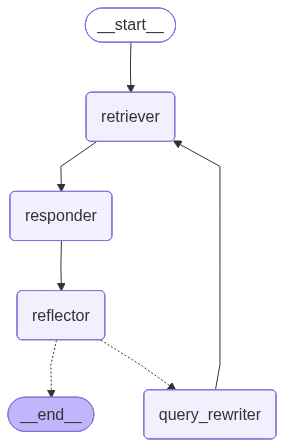

In [32]:
#── LangGraph DAG ─────────────────────────────────────────────────────────────
builder = StateGraph(RAGReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("query_rewriter", rewrite_query)



builder.add_edge(START, "retriever")

builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")

builder.add_conditional_edges(
    "reflector",
    should_continue,
    path_map=["query_rewriter", END]  # ← explicitly declare both possible outputs
)
builder.add_edge("query_rewriter", "retriever")
graph = builder.compile()

logger.info("LangGraph compiled successfully")
graph

In [33]:
if __name__ == "__main__":
    user_query = "What is the meta q3 earnings?"
    logger.info(f"Starting agent with question: '{user_query}'")
    
    init_state = RAGReflectionState(question=user_query, original_question=user_query)
    result = graph.invoke(init_state)  # <-- just pass the state object

    logger.info(f"Agent finished after {result['attempts']} attempt(s)")
    print("\n🧠 Final Answer:\n", result["answer"])
    print("\n🔁 Reflection Log:\n", result["reflection"])
    print("🔄 Total Attempts:", result["attempts"])

2026-02-21 14:46:34,055 [INFO] rag_agent - Starting agent with question: 'What is the meta q3 earnings?'
2026-02-21 14:46:34,061 [INFO] rag_agent - [retrieve_docs] Retrieving docs for question: 'What is the meta q3 earnings?'
2026-02-21 14:46:34,478 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-02-21 14:46:34,480 [INFO] rag_agent - [retrieve_docs] Retrieved 5 documents
2026-02-21 14:46:34,482 [INFO] rag_agent - [generate_answer] Generating answer (attempt 1)
2026-02-21 14:46:36,245 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-21 14:46:36,252 [INFO] rag_agent - [generate_answer] Answer generated successfully
2026-02-21 14:46:36,253 [INFO] rag_agent - [reflect_on_answer] Reflecting on answer (attempt 1)
2026-02-21 14:46:37,830 [INFO] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-21 14:46:37,840 [INFO] rag_agent - [reflect_on_answer] R


🧠 Final Answer:
 In the third quarter of 2025, Meta reported a net income of $2.71 billion. However, this figure includes a one-time, non-cash income tax charge of $15.93 billion. Excluding this charge, Meta's net income would have been $18.64 billion. Meanwhile, the diluted earnings per share (EPS) for Q3 2025 was reported at $1.05, but excluding the one-time tax charge, the EPS would have been $7.25.

🔁 Reflection Log:
 Reflection: YES

Explanation: The answer correctly states that Meta reported a net income of $2.71 billion in Q3 2025, which includes a one-time, non-cash income tax charge of $15.93 billion. It also accurately mentions that excluding this charge, the net income would have been $18.64 billion. Additionally, it correctly reports the diluted earnings per share (EPS) for Q3 2025 as $1.05 and notes that excluding the one-time tax charge, the EPS would have been $7.25.
🔄 Total Attempts: 1
